# Tag Recommendation Experiment (RecSys 2018)

Notebook simple et modulaire pour reproduire une expérience inspirée de l'article **Semantic-based Tag Recommendation in Scientific Bookmarking Systems**.

- Import des données : **1 cellule**
- Une fonction par cellule
- Visualisations déplacées dans `src/visualization.py`
- Dernière cellule : compilation des résultats + visualisations comparatives

In [1]:
import os

FORCE_CPU = False

if FORCE_CPU:
    os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf

if FORCE_CPU:
    print(f"TF {tf.__version__} — forced CPU")
else:
    print(f"TF {tf.__version__} — GPUs: {tf.config.list_physical_devices('GPU')}")
    for g in tf.config.list_physical_devices("GPU"):
        tf.config.experimental.set_memory_growth(g, True)
    tf.config.experimental.enable_tensor_float_32_execution(True)

device = "/CPU:0" if FORCE_CPU else "/GPU:0"
with tf.device(device):
    a = tf.random.normal((1024, 1024))
    _ = tf.matmul(a, a).numpy().sum()
print(f"{'CPU' if FORCE_CPU else 'GPU'} OK on {a.device}")

I0000 00:00:1776546971.562042   34378 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776546972.197488   34378 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF 2.22.0-dev0+selfbuilt — GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU OK on /job:localhost/replica:0/task:0/device:GPU:0


In [2]:
# Cellule 1 - Imports (meme stack que l'article)
import sys
from pathlib import Path
import subprocess
import os

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data import (
    load_citeulike_a_dataset, 
    keep_top_k_tags, 
    preprocess_text_nltk, 
    text_length_stats,
    build_sentence_preprocessed
)
from src.experiment import prepare_train_test, run_all_models, run_all_models_hierarchical
from src.visualization import (
    plot_tag_distribution,
    plot_text_length_distributions,
    plot_model_metrics,
    plot_article_vs_current,
    plot_tag_cooccurrence_heatmap,
    plot_tag_frequency_pareto,
    plot_preprocessing_impact,
    plot_sentences_per_doc,
    plot_training_history,
    plot_training_time,
    plot_per_tag_f1,
    plot_threshold_sensitivity,
    plot_precision_recall_scatter,
    plot_topk_sensitivity,
)
from src.results_save import save_metrics_enriched

# pd.set_option("display.max_colwidth", 120)

In [3]:
# Cellule 2 - Paramètres globaux
DATA_PATH = Path(PROJECT_ROOT / "data" / "citeulike-a")
if not os.path.exists(DATA_PATH):
    print("target =", DATA_PATH.resolve())
    print("exists =", DATA_PATH.exists())
    if not DATA_PATH.exists():
        DATA_PATH.mkdir(parents=True, exist_ok=True)
        result = subprocess.run(
            ["bash","-c", f"git clone https://github.com/js05212/citeulike-a.git data/citeulike-a"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
        result = subprocess.run(
            ["bash","-c", "ls -la data"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
        result = subprocess.run(
            ["bash","-c", f"ls -la {DATA_PATH}"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
GLOVE_PATH = Path(PROJECT_ROOT / "data" / "glove.6B.300d.txt")
if not os.path.exists(GLOVE_PATH):
    print("target =", GLOVE_PATH.resolve())
    print("exists =", GLOVE_PATH.exists())
    if not GLOVE_PATH.exists():
        result = subprocess.run(
            ["bash","-c", "curl -L -o data/glove.6B.zip \
            https://nlp.stanford.edu/data/glove.6B.zip"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
        result = subprocess.run(
            ["bash","-c", "ls -la data"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
        result = subprocess.run(
            ["bash","-c", "unzip data/glove.6B.zip -d data"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
        result = subprocess.run(
            ["bash","-c", f"ls -la {GLOVE_PATH}"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
TOP_K_TAGS = 10
TEST_SIZE = 0.1
RANDOM_STATE = 42

/workspace/data/citeulike-a/citations.dat
/workspace/data/citeulike-a/item-tag.dat
/workspace/data/citeulike-a/mult.dat
/workspace/data/citeulike-a/tags.dat
/workspace/data/citeulike-a/users.dat
/workspace/data/citeulike-a/vocabulary.dat
[Fig] Pareto des tags — part cumulée des occurrences pour les tags triés par fréquence (axe X log). Corpus : 46388 tags uniques. À la coupure top-10, on couvre 4.8% des occurrences totales.
[Fig] Tag Co-occurrence (Jaccard) — heatmap symétrique des 15 tags les plus fréquents. Case claire = les deux tags apparaissent souvent ensemble. Utile pour expliquer les confusions inter-tags en multi-label.


,title,abstract,tags,text,tag_list,processed_text,processed_sentences,title_words,abstract_words,text_words,num_tags
0,The metabolic world of Escherichia coli is not...,To elucidate the organizational and evolutiona...,dissertation|metabolism|network|metabolic_netw...,The metabolic world of Escherichia coli is not...,"[network, review, networks]",metabolic world escherichia coli small elucida...,metabolic world escherichia coli small . eluci...,9,174,119,3
1,Reverse Engineering of Biological Complexity,Advanced technologies and biology have extreme...,behaviors|control|controllability|key--systems...,Reverse Engineering of Biological Complexity. ...,"[networks, network, review, evolution]",reverse engineering biological complexity adva...,reverse engineering biological complexity . ad...,5,123,82,4
2,Exploring complex networks,"The study of networks pervades all of science,...",scalefree|bistability|senior-project|complex-n...,Exploring complex networks. The study of netwo...,"[networks, statistics, network, review]",exploring complex network study network pervad...,exploring complex network . study network perv...,3,99,63,4
3,Comparative assessment of large-scale data set...,Comprehensive protein protein interaction maps...,false|features|pin|network_confidence|ppi|two-...,Comparative assessment of large-scale data set...,"[networks, network, statistics, bioinformatics...",comparative assessment large scale data set pr...,comparative assessment large scale data set pr...,9,61,50,5
4,Navigation in a small world,The small-world phenomenon â the principle t...,diktyology|complex-networks|filing-small-world...,Navigation in a small world. The small-world p...,"[networks, network, analysis]",navigation small world small world phenomenon ...,navigation small world . small world phenomeno...,5,103,60,3


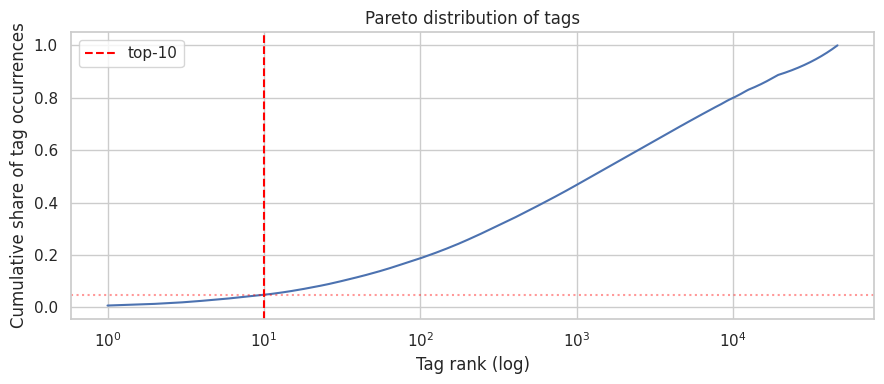

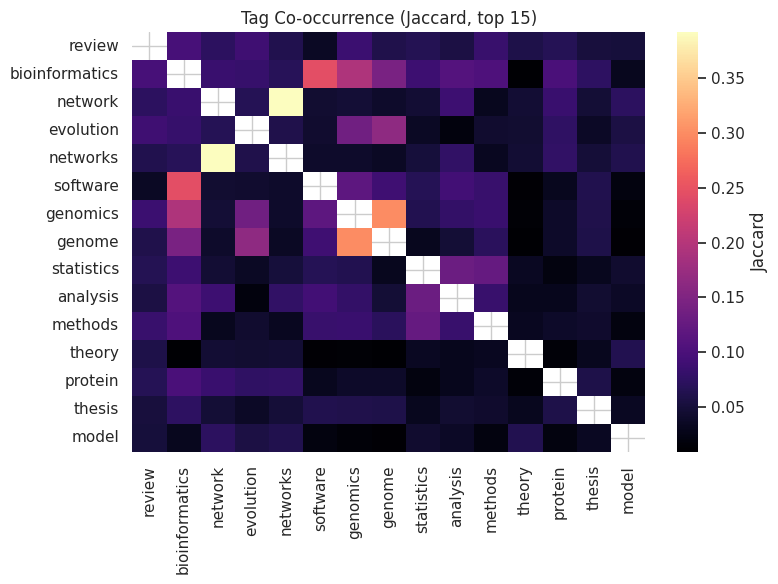

In [4]:
# Cellule 3 - Import des données (simple, en une cellule)
def import_data(csv_path: str | Path, top_k_tags: int = 10):
    df = load_citeulike_a_dataset(csv_path, normalize_tags=False)
    from src.visualization import plot_tag_cooccurrence_heatmap, plot_tag_frequency_pareto
    plot_tag_frequency_pareto(df, cutoff_k=10)
    plot_tag_cooccurrence_heatmap(df, top_n=15)
    df = keep_top_k_tags(df, top_k=top_k_tags)
    df = preprocess_text_nltk(df)
    df = build_sentence_preprocessed(df)
    return text_length_stats(df)


df = import_data(DATA_PATH, TOP_K_TAGS)
df.head()

In [5]:
# Cellule 4 - Fonction de résumé exploration
def summarize_dataset(df: pd.DataFrame) -> pd.DataFrame:
    summary = {
        "num_documents": [len(df)],
        "num_unique_tags": [len({t for tags in df["tag_list"] for t in tags})],
        "avg_title_words": [df["title_words"].mean()],
        "avg_abstract_words": [df["abstract_words"].mean()],
        "avg_tags_per_doc": [df["num_tags"].mean()],
        "vocabulary_size" : len(set(" ".join(df["processed_text"]).split()))
    }
    return pd.DataFrame(summary)


summarize_dataset(df)

,num_documents,num_unique_tags,avg_title_words,avg_abstract_words,avg_tags_per_doc,vocabulary_size
0,6397,10,8.882132,180.848835,1.802251,30799


[Fig] Pareto des tags — part cumulée des occurrences pour les tags triés par fréquence (axe X log). Corpus : 10 tags uniques. À la coupure top-10, on couvre 100.0% des occurrences totales.
[Fig] Top Tag Distribution — fréquence des 10 tags les plus courants dans le corpus (plus la barre est longue, plus le tag apparaît souvent).
[Fig] Tag Co-occurrence (Jaccard) — heatmap symétrique des 10 tags les plus fréquents. Case claire = les deux tags apparaissent souvent ensemble. Utile pour expliquer les confusions inter-tags en multi-label.
[Fig] Text Length Distributions — trois histogrammes côte à côte : longueur des titres (mots), longueur des résumés (mots), et nombre de tags par document. Sert à caler les hyperparamètres (max_len, max_words).


/workspace/src/visualization.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, ax=ax, palette="viridis")


[Fig] Impact du prétraitement NLTK — superpose la distribution du nombre de tokens par document AVANT (bleu) et APRÈS (rouge) nettoyage (stopwords + lemmatization). Réduction globale ≈ 34.4% du volume de tokens.
[Fig] Phrases par document — histogramme du nombre de phrases après segmentation. Médiane = 8. La barre rouge marque le plafond max_sentences=10 utilisé par HAN ; 27.7% des documents sont tronqués à cette valeur.


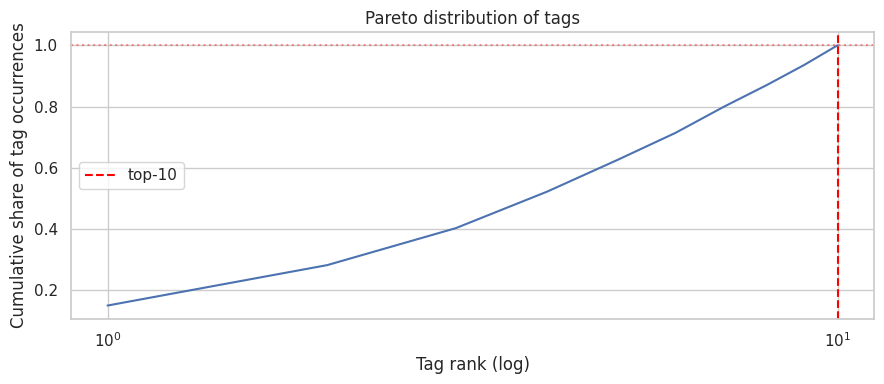

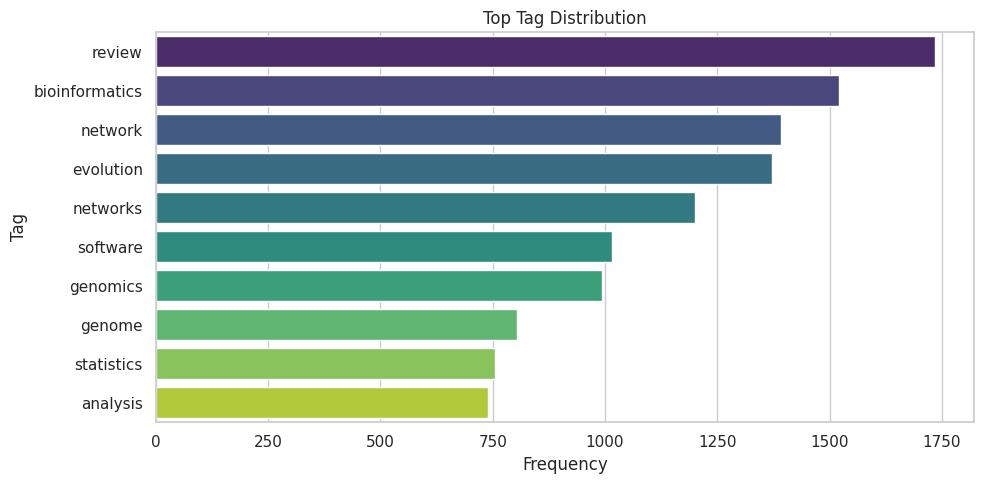

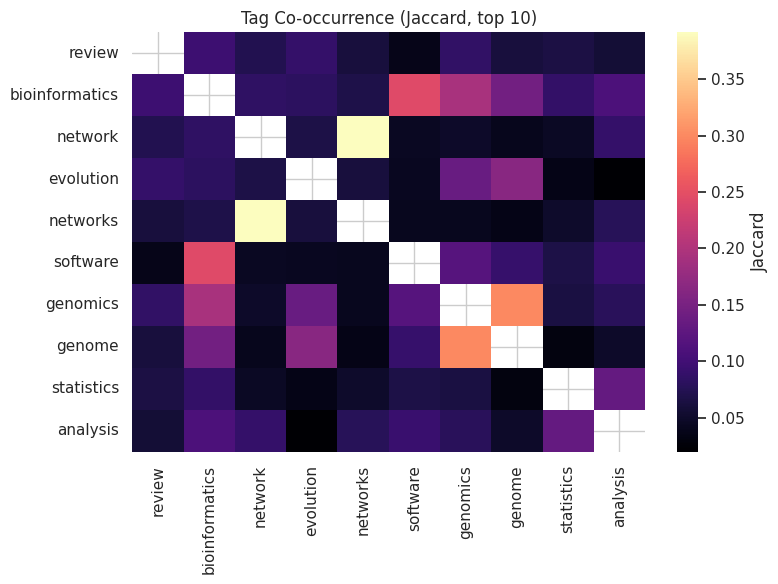

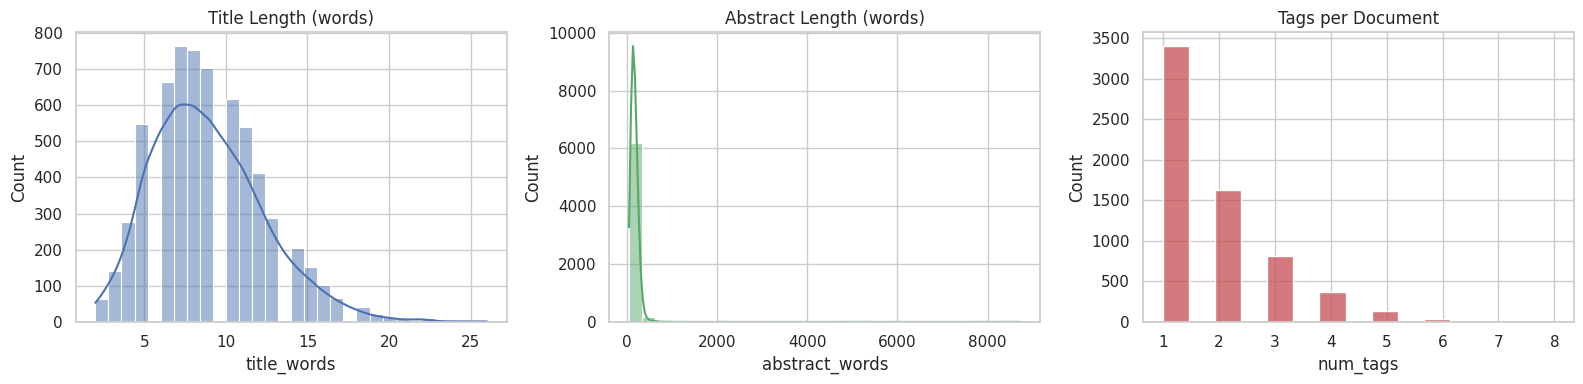

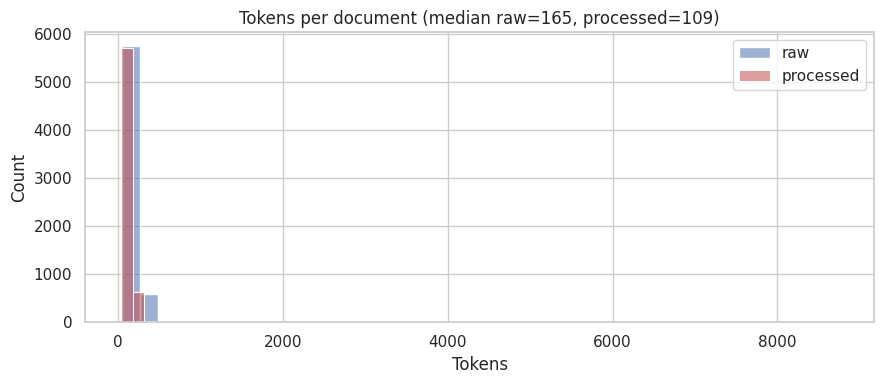

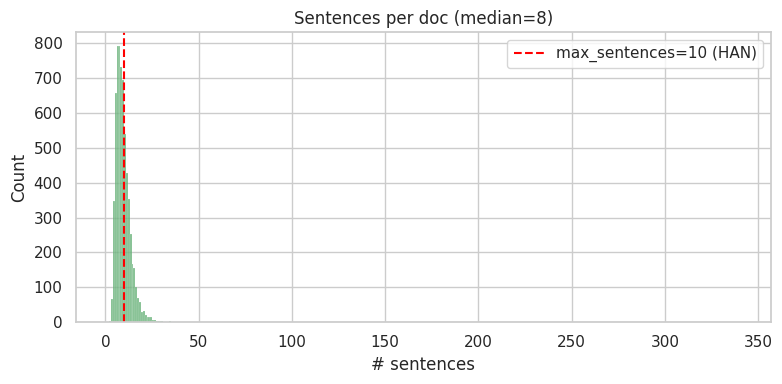

In [6]:
# Cellule 5 - Fonction visualisation EDA
def visualize_eda(df: pd.DataFrame):
    fig_pareto = plot_tag_frequency_pareto(df, cutoff_k=TOP_K_TAGS)
    fig_tags = plot_tag_distribution(df, top_n=TOP_K_TAGS)
    fig_cooc = plot_tag_cooccurrence_heatmap(df, top_n=min(TOP_K_TAGS, 15))
    fig_len = plot_text_length_distributions(df)
    fig_prep = plot_preprocessing_impact(df)
    fig_sents = plot_sentences_per_doc(df)
    plt.show()
    return {
        "pareto": fig_pareto,
        "tags": fig_tags,
        "cooc": fig_cooc,
        "lengths": fig_len,
        "preprocessing": fig_prep,
        "sentences": fig_sents,
    }


_ = visualize_eda(df)

In [7]:
# Cellule 6 - Préparation train/test
def make_splits(df: pd.DataFrame):
    return prepare_train_test(
        df,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )


X_flat_train, X_flat_test, X_hier_train, X_hier_test, y_train, y_test, mlb = make_splits(df)
print("Train:", len(X_flat_train), "Test:", len(X_flat_test), "Labels:", len(mlb.classes_))
print("Hier train:", len(X_hier_train), "Hier test:", len(X_hier_test), "Labels:", len(mlb.classes_))


Train: 5757 Test: 640 Labels: 10
Hier train: 5757 Hier test: 640 Labels: 10


In [8]:
def train_models(X_flat_train, X_flat_test, y_train, y_test, n_topics: int, glove_path: str, threshold: float, topk: int):
    return run_all_models(
        X_train=X_flat_train,
        X_test=X_flat_test,
        y_train=y_train,
        y_test=y_test,
        n_topics=n_topics,
        glove_path=glove_path,
        threshold=threshold,
        topk=topk,
    )

def train_models_hierarchical(X_hier_train, X_hier_test, y_train, y_test, n_topics: int, glove_path: str, threshold: float, topk: int):
    return run_all_models_hierarchical(
        X_hier_train=X_hier_train,
        X_hier_test=X_hier_test,
        y_train=y_train,
        y_test=y_test,
        n_topics=n_topics,
        glove_path=glove_path,
        threshold=threshold,
        topk=topk,
    )


In [9]:
# Mode top-k (aligné article) — k calculé automatiquement depuis y_train
metrics_df, predictions, raw_probas, timings, histories = train_models(
    X_flat_train, X_flat_test, y_train, y_test,
    n_topics=TOP_K_TAGS,
    glove_path=str(GLOVE_PATH),
    threshold=0.5,
    topk=None, # Pour etre coherent avec Wang et al. article 400.pdf
)
metrics_df

Training NB model...
Training SVM model (BOW, calibrated)...
Training LDA model...
Training LDA model (TF-IDF)...
Training Doc2Vec model...
Training Bi-GRU+Attention model...
Building embedding matrix...
Found in embedding matrix 13047 vectors out of 15000
Building Bi-GRU+Attention model...
Epoch 1/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.4860 - val_loss: 0.4629
Epoch 2/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.4491 - val_loss: 0.4402
Epoch 3/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.4209 - val_loss: 0.4073
Epoch 4/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3889 - val_loss: 0.3798
Epoch 5/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3646 - val_loss: 0.3580
Epoch 6/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3481 - val_loss: 0.3451
Epoch 7/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3362 - val_loss: 0.3363
Epoch 8/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3264 - val_loss: 0.3252
Epoch 9/60
81/81 ━━━━━━━━━━━

Model: "HAN_BiGRU_Att"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ doc_input (InputLayer)          │ (None, 10, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ apply_word_encoder              │ (None, 10, 50)         │     4,551,650 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 10, 10)         │         1,710 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sentence_attention              │ (None, 10)             │           600 │
│ (BahdanauAttention)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │           550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tags (Dense)                    │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,555,020 (17.38 MB)

 Trainable params: 55,020 (214.92 KB)

 Non-trainable params: 4,500,000 (17.17 MB)

Epoch 1/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.5023 - val_loss: 0.4682
Epoch 2/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.4683 - val_loss: 0.4681
Epoch 3/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.4658 - val_loss: 0.4685
Epoch 4/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4650 - val_loss: 0.4682
Epoch 5/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4642 - val_loss: 0.4680
Epoch 6/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4641 - val_loss: 0.4676
Epoch 7/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4631 - val_loss: 0.4678
Epoch 8/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4633 - val_loss: 0.4671
Epoch 9/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4613 - val_loss: 0.4640
Epoch 10/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4502 - val_loss: 0.4425
Epoch 11/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4269 - val_loss: 0.4209
Epoch 12/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4

,name,micro_recall,micro_precision,micro_f1
0,Bi-GRU+Att,0.521664,0.740467,0.612100
1,SVM,0.490468,0.764865,0.597677
2,NB,0.757366,0.490736,0.595571
3,Paragraph Vector,0.576256,0.598560,0.587196
4,HAN_BiGRU_Att,0.498267,0.709877,0.585540
5,SVM_BOW,0.330156,0.793750,0.466340
6,LDA,0.220971,0.629630,0.327133
7,LDA_TFIDF,0.000867,0.500000,0.001730


In [10]:
seeds = [42, 123, 456, 789, 1024]
all_metrics = []
for seed in seeds:
    X_flat_train, X_flat_test, X_hier_train, X_hier_test, y_train, y_test, mlb = prepare_train_test(df, random_state=seed)
    metrics, _, _, _, _ = train_models(
    X_flat_train, X_flat_test, y_train, y_test,
    n_topics=TOP_K_TAGS,
    glove_path=str(GLOVE_PATH),
    threshold=0.5,
    topk=None,
    )
    metrics["seed"] = seed
    all_metrics.append(metrics)
df_all = pd.concat(all_metrics)
summary = df_all.groupby("name").agg(["mean", "std"])
summary

Training NB model...
Training SVM model (BOW, calibrated)...
Training LDA model...
Training LDA model (TF-IDF)...
Training Doc2Vec model...
Training Bi-GRU+Attention model...
Building embedding matrix...
Found in embedding matrix 13047 vectors out of 15000
Building Bi-GRU+Attention model...
Epoch 1/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4968 - val_loss: 0.4638
Epoch 2/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.4497 - val_loss: 0.4405
Epoch 3/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.4148 - val_loss: 0.4003
Epoch 4/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3766 - val_loss: 0.3674
Epoch 5/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3534 - val_loss: 0.3528
Epoch 6/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3384 - val_loss: 0.3401
Epoch 7/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3281 - val_loss: 0.3306
Epoch 8/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3198 - val_loss: 0.3220
Epoch 9/60
81/81 ━━━━━━━━━━━

Model: "HAN_BiGRU_Att"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ doc_input (InputLayer)          │ (None, 10, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ apply_word_encoder              │ (None, 10, 50)         │     4,551,650 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 10, 10)         │         1,710 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sentence_attention              │ (None, 10)             │           600 │
│ (BahdanauAttention)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 50)             │           550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tags (Dense)                    │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,555,020 (17.38 MB)

 Trainable params: 55,020 (214.92 KB)

...

 Total params: 4,555,020 (17.38 MB)

 Trainable params: 55,020 (214.92 KB)

 Non-trainable params: 4,500,000 (17.17 MB)

Epoch 1/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.4994 - val_loss: 0.4700
Epoch 2/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.4654 - val_loss: 0.4698
Epoch 3/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4632 - val_loss: 0.4698
Epoch 4/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4624 - val_loss: 0.4697
Epoch 5/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4618 - val_loss: 0.4694
Epoch 6/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4611 - val_loss: 0.4692
Epoch 7/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4611 - val_loss: 0.4687
Epoch 8/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4602 - val_loss: 0.4678
Epoch 9/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4581 - val_loss: 0.4645
Epoch 10/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4498 - val_loss: 0.4428
Epoch 11/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4264 - val_loss: 0.4177
Epoch 12/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4

micro_recall           micro_precision            micro_f1  \
                         mean       std            mean       std      mean   
name                                                                          
Bi-GRU+Att           0.546883  0.022940        0.701859  0.021508  0.614341   
HAN_BiGRU_Att        0.467675  0.029179        0.698956  0.021614  0.559795   
LDA                  0.230049  0.030947        0.667389  0.039399  0.341081   
LDA_TFIDF            0.036083  0.028764        0.576132  0.061021  0.066241   
NB                   0.766688  0.008102        0.501711  0.018773  0.606383   
Paragraph Vector     0.574233  0.006645        0.590812  0.015810  0.582294   
SVM                  0.487983  0.015799        0.759822  0.018785  0.594028   
SVM_BOW              0.318150  0.010882        0.775354  0.018841  0.451087   

                             seed              
                       std   mean         std  
name                                           
Bi-GRU+Att        0.014250  486.8  421.620327  
HAN_BiGRU_Att     0.021167  486.8  421.620327  
LDA               0.035147  486.8  421.620327  
LDA_TFIDF         0.051379  486.8  421.620327  
NB                0.014614  486.8  421.620327  
Paragraph Vector  0.007820  486.8  421.620327  
SVM               0.010513  486.8  421.620327  
SVM_BOW           0.012518  486.8  421.620327

In [11]:
# Mode top-k (aligné article) — k calculé automatiquement depuis y_train
metrics_df, predictions, raw_probas, timings, histories = train_models_hierarchical(
    X_hier_train, X_hier_test, y_train, y_test,
    n_topics=TOP_K_TAGS,
    glove_path=str(GLOVE_PATH),
    threshold=0.5,
    topk=None, # Pour etre coherent avec Wang et al. article 400.pdf
)
metrics_df

Training NB model...
Training SVM model (BOW, calibrated)...
Training LDA model...
Training LDA model (TF-IDF)...
Training Doc2Vec model...
Training Bi-GRU+Attention model...
Building embedding matrix...
Found in embedding matrix 13033 vectors out of 15000
Building Bi-GRU+Attention model...
Epoch 1/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4854 - val_loss: 0.4660
Epoch 2/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.4519 - val_loss: 0.4512
Epoch 3/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.4247 - val_loss: 0.4040
Epoch 4/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3795 - val_loss: 0.3595
Epoch 5/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3522 - val_loss: 0.3476
Epoch 6/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3391 - val_loss: 0.3330
Epoch 7/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3288 - val_loss: 0.3205
Epoch 8/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3200 - val_loss: 0.3149
Epoch 9/60
81/81 ━━━━━━━━━━━

Model: "HAN_BiGRU_Att"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ doc_input (InputLayer)          │ (None, 10, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ apply_word_encoder              │ (None, 10, 50)         │     4,551,650 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_20                │ (None, 10, 10)         │         1,710 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sentence_attention              │ (None, 10)             │           600 │
│ (BahdanauAttention)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 50)             │           550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tags (Dense)                    │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,555,020 (17.38 MB)

 Trainable params: 55,020 (214.92 KB)

 Non-trainable params: 4,500,000 (17.17 MB)

Epoch 1/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.5005 - val_loss: 0.4706
Epoch 2/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4643 - val_loss: 0.4697
Epoch 3/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.4623 - val_loss: 0.4692
Epoch 4/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.4611 - val_loss: 0.4681
Epoch 5/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4582 - val_loss: 0.4627
Epoch 6/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4427 - val_loss: 0.4287
Epoch 7/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4128 - val_loss: 0.3991
Epoch 8/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.3964 - val_loss: 0.3838
Epoch 9/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.3812 - val_loss: 0.3688
Epoch 10/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.3633 - val_loss: 0.3514
Epoch 11/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.3476 - val_loss: 0.3377
Epoch 12/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.3

,name,micro_recall,micro_precision,micro_f1
0,NB,0.768856,0.533183,0.629691
1,Bi-GRU+Att,0.523925,0.736602,0.612322
2,SVM,0.472019,0.790761,0.591163
3,Paragraph Vector,0.557178,0.620596,0.587179
4,HAN_BiGRU_Att,0.480941,0.733911,0.581088
5,SVM_BOW,0.312247,0.797101,0.448718
6,LDA,0.256285,0.708520,0.376415
7,LDA_TFIDF,0.022709,0.736842,0.044060


In [12]:
seeds = [42, 123, 456, 789, 1024]
all_metrics = []
for seed in seeds:
    X_flat_train, X_flat_test, X_hier_train, X_hier_test, y_train, y_test, mlb = prepare_train_test(df, random_state=seed)
    metrics, _, _, _, _ = train_models_hierarchical(
    X_hier_train, X_hier_test, y_train, y_test,
    n_topics=TOP_K_TAGS,
    glove_path=str(GLOVE_PATH),
    threshold=0.5,
    topk=None,
    )
    metrics["seed"] = seed
    all_metrics.append(metrics)
df_all = pd.concat(all_metrics)
summary = df_all.groupby("name").agg(["mean", "std"])
summary

Training NB model...
Training SVM model (BOW, calibrated)...
Training LDA model...
Training LDA model (TF-IDF)...
Training Doc2Vec model...
Training Bi-GRU+Attention model...
Building embedding matrix...
Found in embedding matrix 13063 vectors out of 15000
Building Bi-GRU+Attention model...
Epoch 1/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.5003 - val_loss: 0.4667
Epoch 2/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.4583 - val_loss: 0.4561
Epoch 3/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.4388 - val_loss: 0.4304
Epoch 4/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.4064 - val_loss: 0.3948
Epoch 5/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3729 - val_loss: 0.3645
Epoch 6/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3507 - val_loss: 0.3487
Epoch 7/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3371 - val_loss: 0.3395
Epoch 8/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3275 - val_loss: 0.3305
Epoch 9/60
81/81 ━━━━━━━━━━━

Model: "HAN_BiGRU_Att"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ doc_input (InputLayer)          │ (None, 10, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ apply_word_encoder              │ (None, 10, 50)         │     4,551,650 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_23                │ (None, 10, 10)         │         1,710 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sentence_attention              │ (None, 10)             │           600 │
│ (BahdanauAttention)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 50)             │           550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tags (Dense)                    │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,555,020 (17.38 MB)

 Trainable params: 55,020 (214.92 KB)

...

 Total params: 4,555,020 (17.38 MB)

 Trainable params: 55,020 (214.92 KB)

 Non-trainable params: 4,500,000 (17.17 MB)

Epoch 1/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.4992 - val_loss: 0.4696
Epoch 2/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4647 - val_loss: 0.4690
Epoch 3/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4630 - val_loss: 0.4675
Epoch 4/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4564 - val_loss: 0.4561
Epoch 5/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4382 - val_loss: 0.4288
Epoch 6/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4189 - val_loss: 0.4149
Epoch 7/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4034 - val_loss: 0.3937
Epoch 8/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.3846 - val_loss: 0.3741
Epoch 9/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.3698 - val_loss: 0.3598
Epoch 10/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.3544 - val_loss: 0.3456
Epoch 11/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.3469 - val_loss: 0.3402
Epoch 12/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.3

micro_recall           micro_precision            micro_f1  \
                         mean       std            mean       std      mean   
name                                                                          
Bi-GRU+Att           0.538479  0.015649        0.710253  0.021217  0.612244   
HAN_BiGRU_Att        0.491424  0.009081        0.707789  0.015499  0.579935   
LDA                  0.241550  0.018521        0.643533  0.045688  0.350819   
LDA_TFIDF            0.024282  0.010985        0.615016  0.083021  0.046401   
NB                   0.766861  0.007832        0.501586  0.018236  0.606354   
Paragraph Vector     0.572139  0.013175        0.597166  0.014683  0.584208   
SVM                  0.487997  0.016918        0.758782  0.019590  0.593712   
SVM_BOW              0.321403  0.012891        0.779617  0.017396  0.455063   

                             seed              
                       std   mean         std  
name                                           
Bi-GRU+Att        0.009377  486.8  421.620327  
HAN_BiGRU_Att     0.004576  486.8  421.620327  
LDA               0.022591  486.8  421.620327  
LDA_TFIDF         0.020626  486.8  421.620327  
NB                0.014228  486.8  421.620327  
Paragraph Vector  0.007898  486.8  421.620327  
SVM               0.012030  486.8  421.620327  
SVM_BOW           0.014501  486.8  421.620327

In [13]:
# If you still have 'predictions' dict from the last run:
y_pred_bigru = predictions["Bi-GRU+Att"]

print("=== Bi-GRU+Att Diagnostic ===")
print(f"y_test shape: {y_test.shape}")
print(f"y_test pos rate: {y_test.mean():.4f}")
print(f"y_test avg labels/doc: {y_test.sum(axis=1).mean():.2f}")
print()
print(f"y_pred shape: {y_pred_bigru.shape}")
print(f"y_pred pos rate: {y_pred_bigru.mean():.4f}")
print(f"y_pred avg labels/doc: {y_pred_bigru.sum(axis=1).mean():.2f}")
print()

# If you can access raw probas (before thresholding), inspect them:
# Otherwise, these stats on binary preds are already very telling
print(f"Docs with 0 predicted tags: {(y_pred_bigru.sum(axis=1) == 0).sum()}")
print(f"Docs with >10 predicted tags: {(y_pred_bigru.sum(axis=1) > 10).sum()}")
print(f"Docs with >20 predicted tags: {(y_pred_bigru.sum(axis=1) > 20).sum()}")

=== Bi-GRU+Att Diagnostic ===
y_test shape: (640, 10)
y_test pos rate: 0.1927
y_test avg labels/doc: 1.93

y_pred shape: (640, 10)
y_pred pos rate: 0.1370
y_pred avg labels/doc: 1.37

Docs with 0 predicted tags: 78
Docs with >10 predicted tags: 0
Docs with >20 predicted tags: 0


In [14]:
# Cellule 8 - Sauvegarde facultative des métriques
   
model_params = {
    "NB": {"vectorizer": "CountVectorizer", "max_features": 8000, "ngram_range": [1, 1], "threshold": 0.5},
    "SVM": {"vectorizer": "TfidfVectorizer", "max_features": 8000, "classifier": "CalibratedClassifierCV(LinearSVC", "threshold": 0.0},
    "LDA": {"num_topics": TOP_K_TAGS, "passes": 10, "iterations": 100, "threshold": 0.5},
    "Paragraph Vector": {"vector_size": 200, "window": 3, "epochs": 20, "threshold": 0.5},
    "Bi-GRU+Att": {"max_words": 15000, "max_len": 300, "gru_units": 25, "dense_units": 50, "dropout": 0.2, "epochs": 5, "batch_size": 64, "threshold": 0.5},
}

save_metrics_enriched(
    metrics_df=metrics_df,
    predictions=predictions,
    y_test=y_test,
    top_k_tags=TOP_K_TAGS,
    test_size=0.1,
    random_state=42,
    repeats=1,
    threshold=0.5,
    n_docs=len(df),
    n_unique_tags=len({t for tags in df["tag_list"] for t in tags}),
    avg_tags_per_doc=float(df["tag_list"].apply(len).mean()),
    glove_path=str(GLOVE_PATH),
    model_params=model_params,
    notes="first stable docker run",
)


(PosixPath('data/metrics_results_history_10.csv'), '2e22927c76d4')

,name,micro_recall,micro_precision,micro_f1
0,NB,0.768856,0.533183,0.629691
1,Bi-GRU+Att,0.523925,0.736602,0.612322
2,SVM,0.472019,0.790761,0.591163
3,Paragraph Vector,0.557178,0.620596,0.587179
4,HAN_BiGRU_Att,0.480941,0.733911,0.581088
5,SVM_BOW,0.312247,0.797101,0.448718
6,LDA,0.256285,0.708520,0.376415
7,LDA_TFIDF,0.022709,0.736842,0.044060


[Fig] Model Comparison — barres groupées de micro-precision / micro-recall / micro-F1 pour chaque modèle. Meilleur modèle : NB (F1=0.630).
[Fig] Article vs Current — compare nos scores (micro P/R/F1) à ceux rapportés dans Wang et al. pour les mêmes modèles. Permet d'évaluer la reproduction.
[Fig] Precision vs Recall (iso-F1) — chaque point est un modèle, positionné selon son micro-recall (X) et sa micro-precision (Y). Les courbes grises pointillées sont les iso-F1 ; un modèle au-dessus d'une courbe dépasse ce F1. Point le plus au nord-est = meilleur compromis (NB, F1=0.630).
[Fig] Temps d'entraînement par modèle (échelle log) — plus rapide : NB (0.2s), plus lent : HAN_BiGRU_Att (69.7s). Ratio lent/rapide ≈ 316×.
[Fig] Courbes d'apprentissage (Bi-GRU+Att) — évolution de la loss par époque. Train loss finale = 0.2615, val loss finale = 0.2950. Si la val loss remonte alors que la train continue de baisser → signe d'overfitting ; early stopping (patience=5) s'en charge.
[Fig] Courbes d'app

/workspace/src/visualization.py:253: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=s.values, y=s.index, ax=ax, palette="crest")


[Fig] F1 par tag et par modèle — heatmap (tags en lignes triés par F1 moyen, modèles en colonnes). Case claire = bien appris, case sombre = mal appris. Tag le mieux prédit : 'evolution' — tag le plus difficile : 'analysis'.
[Fig] Sensibilité au seuil — micro-F1 en fonction du seuil de binarisation (balayage de 0.05 à 0.95). Le maximum de chaque courbe indique le seuil optimal pour le modèle correspondant ; si le pic est loin de 0.5, le 0.5 par défaut est sous-optimal.
[Fig] Sensibilité au top-K — micro-F1 quand on force la prédiction des K tags les plus probables par document (K de 1 à 5). Permet de choisir K quand on veut un nombre fixe de recommandations plutôt qu'un seuil de probabilité.
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding top-k...
Thresholding t

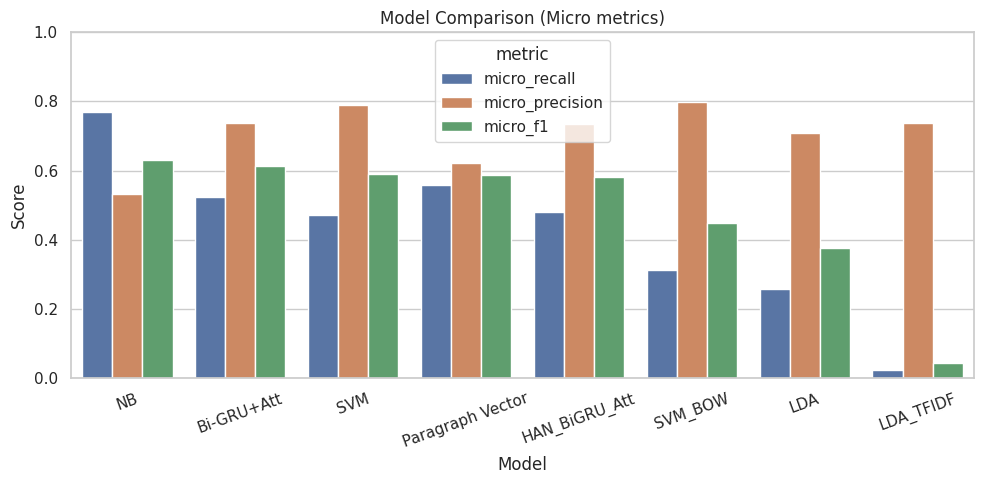

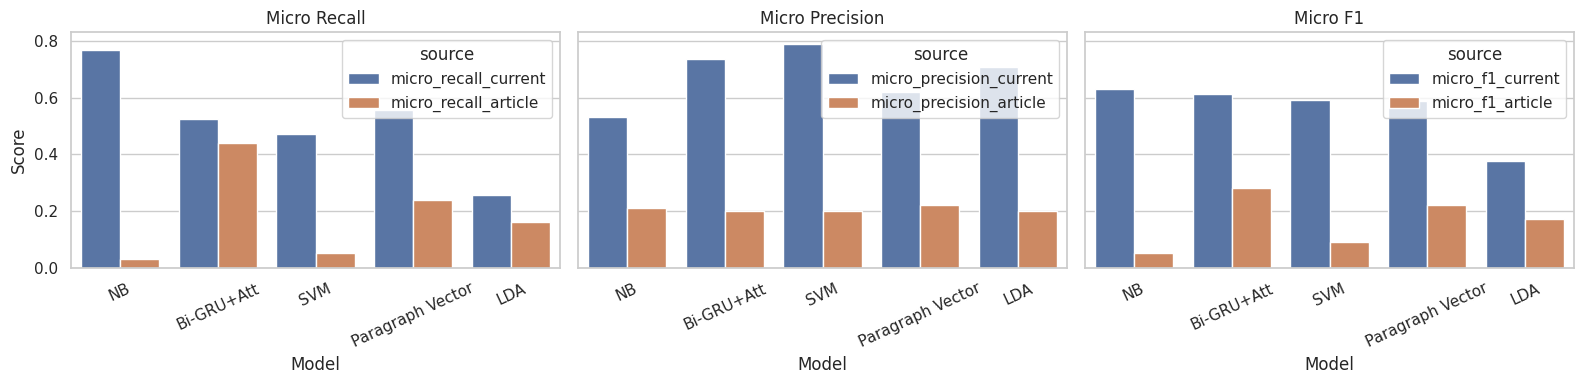

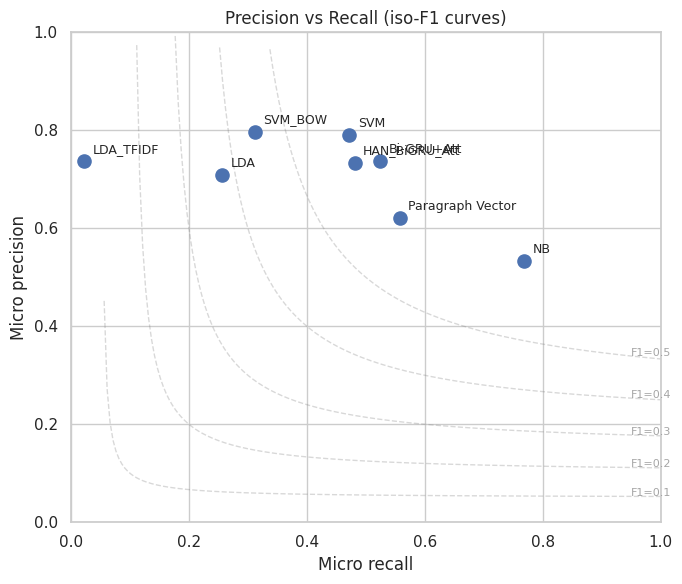

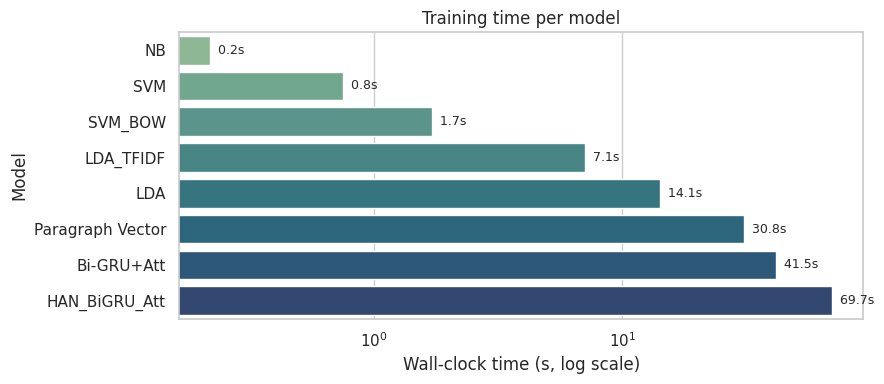

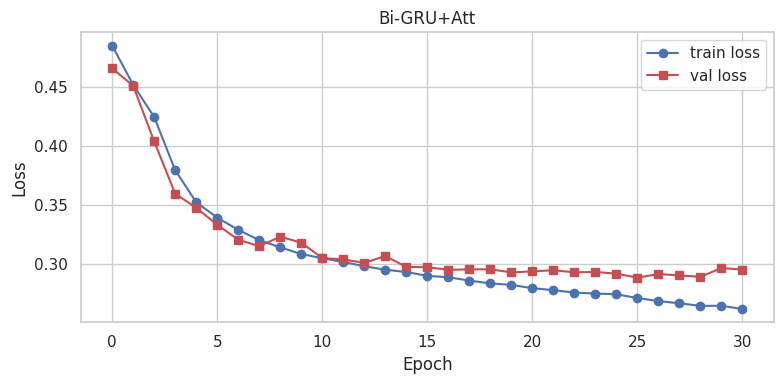

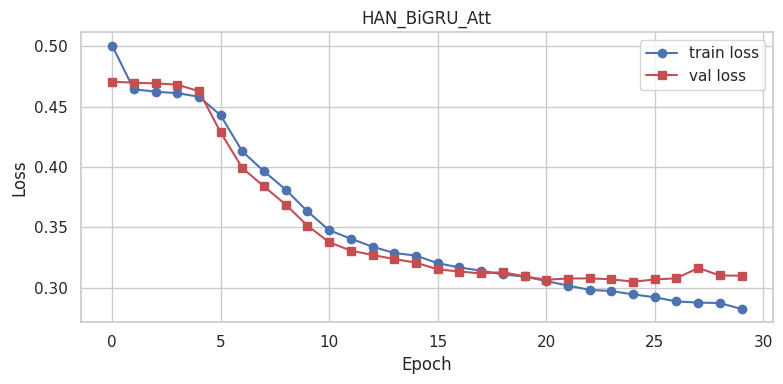

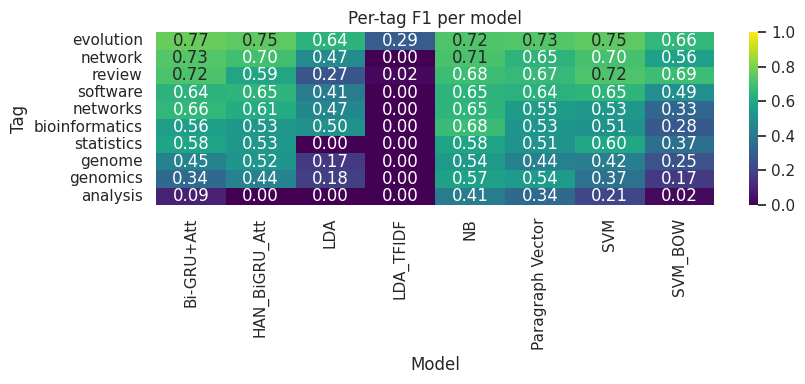

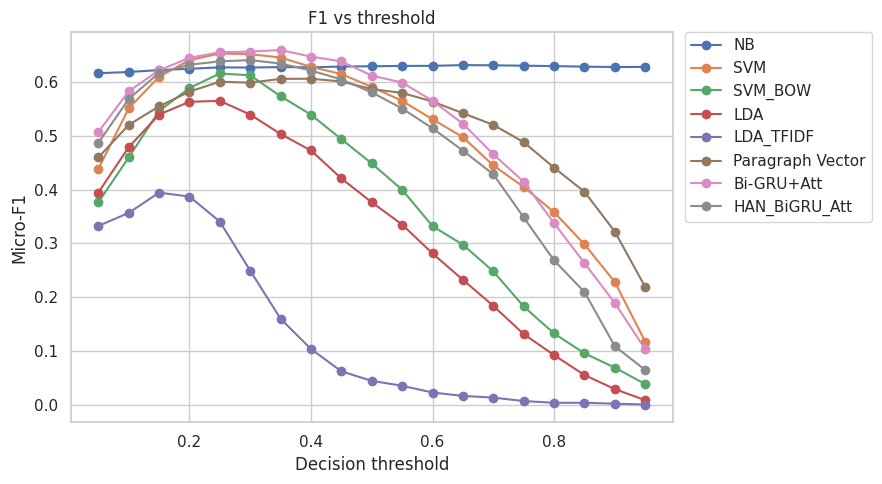

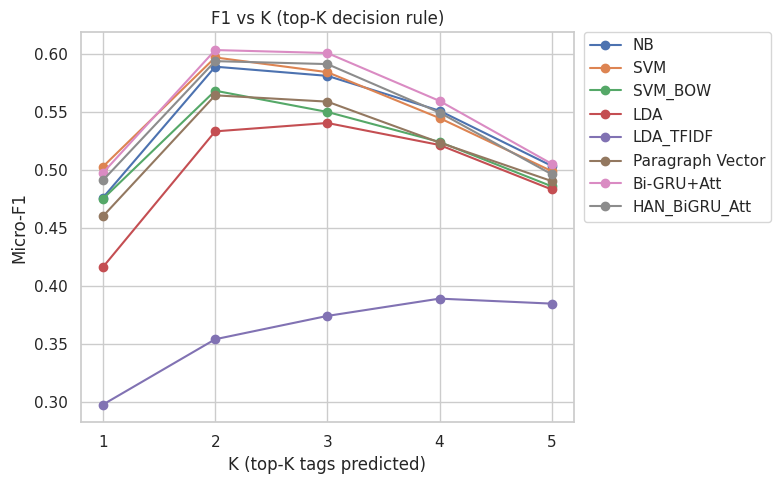

{'best_model': 'NB',
 'best_micro_f1': 0.6296911325141149,
 'timings_s': {'NB': 0.22,
  'SVM': 0.75,
  'SVM_BOW': 1.72,
  'LDA': 14.09,
  'LDA_TFIDF': 7.08,
  'Paragraph Vector': 30.79,
  'Bi-GRU+Att': 41.54,
  'HAN_BiGRU_Att': 69.7}}

In [15]:
# Cellule 9 (dernière) - Compilation + visualisations comparatives
def compile_and_compare(
    metrics_df: pd.DataFrame,
    predictions: dict,
    raw_probas: dict,
    timings: dict,
    histories: dict,
    y_test,
    mlb,
):
    display(metrics_df.sort_values("micro_f1", ascending=False).reset_index(drop=True))

    # --- 1. Comparaison synthétique des modèles ---
    fig_models = plot_model_metrics(metrics_df)
    fig_article = plot_article_vs_current(metrics_df)
    fig_pr = plot_precision_recall_scatter(metrics_df)

    # --- 2. Entraînement (temps + courbes pour les NN) ---
    fig_time = plot_training_time(timings)
    for nn_name in ("Bi-GRU+Att", "HAN_BiGRU_Att"):
        if nn_name in histories and histories[nn_name]:
            plot_training_history(histories[nn_name], title=nn_name)

    # --- 3. Diagnostic par tag / sensibilité ---
    fig_per_tag = plot_per_tag_f1(y_test, predictions, tag_names=mlb.classes_.tolist())
    fig_thr = plot_threshold_sensitivity(y_test, raw_probas)
    fig_topk = plot_topk_sensitivity(y_test, raw_probas, k_values=range(1, 6))
    plt.show()

    return {
        "best_model": metrics_df.sort_values("micro_f1", ascending=False).iloc[0]["name"],
        "best_micro_f1": float(metrics_df["micro_f1"].max()),
        "timings_s": {k: round(v, 2) for k, v in timings.items()},
    }


summary = compile_and_compare(
    metrics_df=metrics_df,
    predictions=predictions,
    raw_probas=raw_probas,
    timings=timings,
    histories=histories,
    y_test=y_test,
    mlb=mlb,
)
summary